# NB06 · Abstractive Summarization with T5

**Goal:** Generate and evaluate abstractive summaries for each complaint cluster using `t5-base`. Produce ROUGE consistency scores and WordCloud visualizations.

| Detail | Value |
|---|---|
| Input | `data/processed/clustered_data.csv` |
| Environment | Google Colab (T4 GPU) |
| Expected runtime | ~15–20 minutes |
| Outputs | `outputs/figures/06_wordclouds.png`, `outputs/figures/06_rouge_scores.png`, summary table |

## 6.1 Colab Setup

In [ ]:
import torch
assert torch.cuda.is_available(), "GPU required"
print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

!pip install -q "rouge-score" "wordcloud" "transformers"

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import T5Tokenizer, T5ForConditionalGeneration
from rouge_score import rouge_scorer
from wordcloud import WordCloud
import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE       = 42
MODEL_NAME         = "t5-base"
N_BATCHES          = 5
N_SAMPLES_PER_BATCH = 15
MAX_INPUT_LEN      = 512
MAX_SUMMARY_LEN    = 150
MIN_SUMMARY_LEN    = 60
NUM_BEAMS          = 4

device = torch.device("cuda")
np.random.seed(RANDOM_STATE)

CLUSTER_LABELS = {
    0: "Credit Report Disputes",
    1: "Debt Collection & Recovery",
    2: "Card Payments & Account Calls",
}
print("✓ Setup complete")

✓ GPU: Tesla T4
✓ Setup complete


## 6.2 Mount Drive & Load Data

In [10]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/cfpb_pipeline/data/processed/clustered_data.csv"
FIG_DIR   = "/content/drive/MyDrive/cfpb_pipeline/outputs/figures"
SUM_DIR   = "/content/drive/MyDrive/cfpb_pipeline/outputs/summaries"
for d in [FIG_DIR, SUM_DIR]:
    os.makedirs(d, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

print(f"{'Cluster':<6}  {'Label':<35}  {'Count':>7}  {'%':>6}")
print("-" * 60)
for c in sorted(df["cluster"].unique()):
    n = (df["cluster"] == c).sum()
    print(f"  {c:<4}  {CLUSTER_LABELS[c]:<35}  {n:>7,}  {n/len(df)*100:>5.1f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 19,997 rows × 14 columns

Cluster  Label                                  Count       %
------------------------------------------------------------
  0     Credit Report Disputes                 8,672   43.4%
  1     Debt Collection & Recovery             3,668   18.3%
  2     Card Payments & Account Calls          7,657   38.3%


## 6.3 Load T5-base

In [11]:
tokenizer_t5 = T5Tokenizer.from_pretrained(MODEL_NAME)
model_t5     = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)
model_t5.eval()
print(f"✓ {MODEL_NAME} loaded  |  params: {sum(p.numel() for p in model_t5.parameters()):,}")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✓ t5-base loaded  |  params: 222,903,552


## 6.4 Summarization Helpers

| Function | Purpose |
|---|---|
| `create_cluster_input()` | Samples *n* complaints from a cluster, concatenates them, and prepends the T5 `"summarize: "` prefix |
| `summarize_text()` | Tokenizes the input, runs beam-search generation, and decodes the output |
| `summarize_cluster()` | Repeats the above *n_batches* times with different random seeds to measure consistency |

In [12]:
def create_cluster_input(df, cluster_id, n_samples, random_state):
    pool    = df[df["cluster"] == cluster_id]
    sample  = pool.sample(n=min(n_samples, len(pool)), random_state=random_state)
    combined = " ".join(sample["text_clean"].tolist())
    return "summarize: " + combined

def summarize_text(text):
    inputs = tokenizer_t5(
        text,
        return_tensors="pt",
        max_length=MAX_INPUT_LEN,
        truncation=True,
    ).to(device)
    with torch.no_grad():
        ids = model_t5.generate(
            inputs.input_ids,
            max_length=MAX_SUMMARY_LEN,
            min_length=MIN_SUMMARY_LEN,
            num_beams=NUM_BEAMS,
            length_penalty=2.0,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    return tokenizer_t5.decode(ids[0], skip_special_tokens=True)

def summarize_cluster(df, cluster_id, n_batches, n_samples):
    return [
        summarize_text(create_cluster_input(df, cluster_id, n_samples, RANDOM_STATE + i))
        for i in range(n_batches)
    ]

test_input = create_cluster_input(df, 0, 5, RANDOM_STATE)
test_summary = summarize_text(test_input)
print(f"Unit test — Cluster 0 (5 samples):")
print(f"  Input length:   {len(test_input.split())} words")
print(f"  Summary length: {len(test_summary.split())} words")
print(f"  Summary: {test_summary[:200]}…")

Unit test — Cluster 0 (5 samples):
  Input length:   451 words
  Summary length: 45 words
  Summary: cfpb has filed a complaint against credit reporting agency experian. complaint alleges fraud and identity theft resulting in inaccurate credit report items. ftc says it has not responded to the compla…


## 6.5 Generate All Summaries

For each of the 3 clusters, 5 independent batches of 15 randomly sampled complaints are summarized. This yields 5 candidate summaries per cluster whose consistency is measured in §6.6.

In [13]:
all_summaries = {}

for c in sorted(CLUSTER_LABELS.keys()):
    t0 = time.time()
    print(f"\nCluster {c} — {CLUSTER_LABELS[c]}")
    summaries = summarize_cluster(df, c, N_BATCHES, N_SAMPLES_PER_BATCH)
    elapsed = time.time() - t0
    all_summaries[c] = summaries

    print(f"  Generated {len(summaries)} summaries in {elapsed:.1f}s")

    lengths = [len(s.split()) for s in summaries]
    best_idx = np.argmax(lengths)
    print(f"  Word counts: {lengths}  |  selecting batch {best_idx} (longest)")
    print(f"  Best summary:\n    {summaries[best_idx]}\n")

print("✓ All summaries generated")


Cluster 0 — Credit Report Disputes
  Generated 5 summaries in 19.4s
  Word counts: [45, 61, 80, 49, 90]  |  selecting batch 4 (longest)
  Best summary:
    i disputed this collection with after not agreeing to information on credit report now i have a missed payment on my credit report reporting from closed collection that has been charged off this is not right and should be removed. i am filing this complaint for falsely reporting misleading information there is no way for a company to falsely report incorrect information. my name is lvnv funding llc my credit card was closed on with revvi i don t understand why this company would falsely reported incorrect information on my


Cluster 1 — Debt Collection & Recovery
  Generated 5 summaries in 35.1s
  Word counts: [56, 77, 87, 79, 91]  |  selecting batch 4 (longest)
  Best summary:
    i am disputing the collection account with account number dated year with a balance of this account is unverified and does not belong to me. i had my id

## 6.6 ROUGE Evaluation

For each cluster the 5 batch summaries are compared pairwise using ROUGE-1, ROUGE-2, and ROUGE-L F1. High pairwise scores indicate that the model produces **consistent** themes regardless of which complaints are sampled.

Cluster  Label                                 ROUGE-1   ROUGE-2   ROUGE-L   Pairs
--------------------------------------------------------------------------------
  0     Credit Report Disputes                 0.3300    0.0733    0.1808      10
  1     Debt Collection & Recovery             0.2643    0.0278    0.1420      10
  2     Card Payments & Account Calls          0.2973    0.0244    0.1507      10


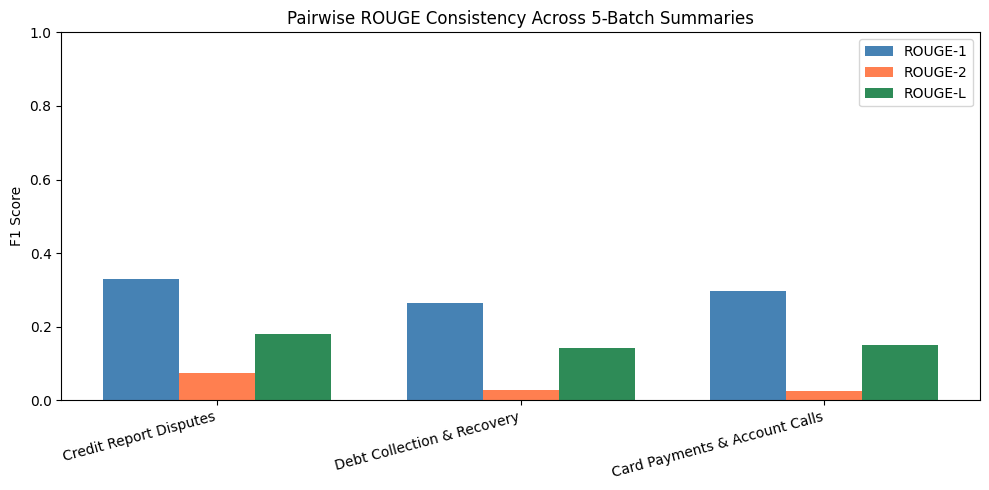

In [14]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

rouge_results = []

for c in sorted(CLUSTER_LABELS.keys()):
    summaries = all_summaries[c]
    r1_scores, r2_scores, rl_scores = [], [], []

    for i in range(len(summaries)):
        for j in range(i + 1, len(summaries)):
            scores = scorer.score(summaries[i], summaries[j])
            r1_scores.append(scores["rouge1"].fmeasure)
            r2_scores.append(scores["rouge2"].fmeasure)
            rl_scores.append(scores["rougeL"].fmeasure)

    rouge_results.append({
        "cluster":       c,
        "label":         CLUSTER_LABELS[c],
        "rouge1_mean":   np.mean(r1_scores),
        "rouge2_mean":   np.mean(r2_scores),
        "rougeL_mean":   np.mean(rl_scores),
        "n_pairs":       len(r1_scores),
    })

rouge_df = pd.DataFrame(rouge_results)

print(f"{'Cluster':<6}  {'Label':<35}  {'ROUGE-1':>8}  {'ROUGE-2':>8}  {'ROUGE-L':>8}  {'Pairs':>6}")
print("-" * 80)
for _, row in rouge_df.iterrows():
    print(f"  {int(row['cluster']):<4}  {row['label']:<35}  "
          f"{row['rouge1_mean']:>8.4f}  {row['rouge2_mean']:>8.4f}  "
          f"{row['rougeL_mean']:>8.4f}  {int(row['n_pairs']):>6}")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rouge_df))
width = 0.25

ax.bar(x - width, rouge_df["rouge1_mean"], width, label="ROUGE-1", color="steelblue")
ax.bar(x,         rouge_df["rouge2_mean"], width, label="ROUGE-2", color="coral")
ax.bar(x + width, rouge_df["rougeL_mean"], width, label="ROUGE-L", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels([CLUSTER_LABELS[c] for c in rouge_df["cluster"]], rotation=15, ha="right")
ax.set(ylabel="F1 Score", title="Pairwise ROUGE Consistency Across 5-Batch Summaries")
ax.legend()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_rouge_scores.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.7 WordClouds

A 1 × 3 grid of word clouds built from the lemmatized `text_processed` column for each cluster. These provide a quick visual sanity check that cluster themes align with the generated summaries.

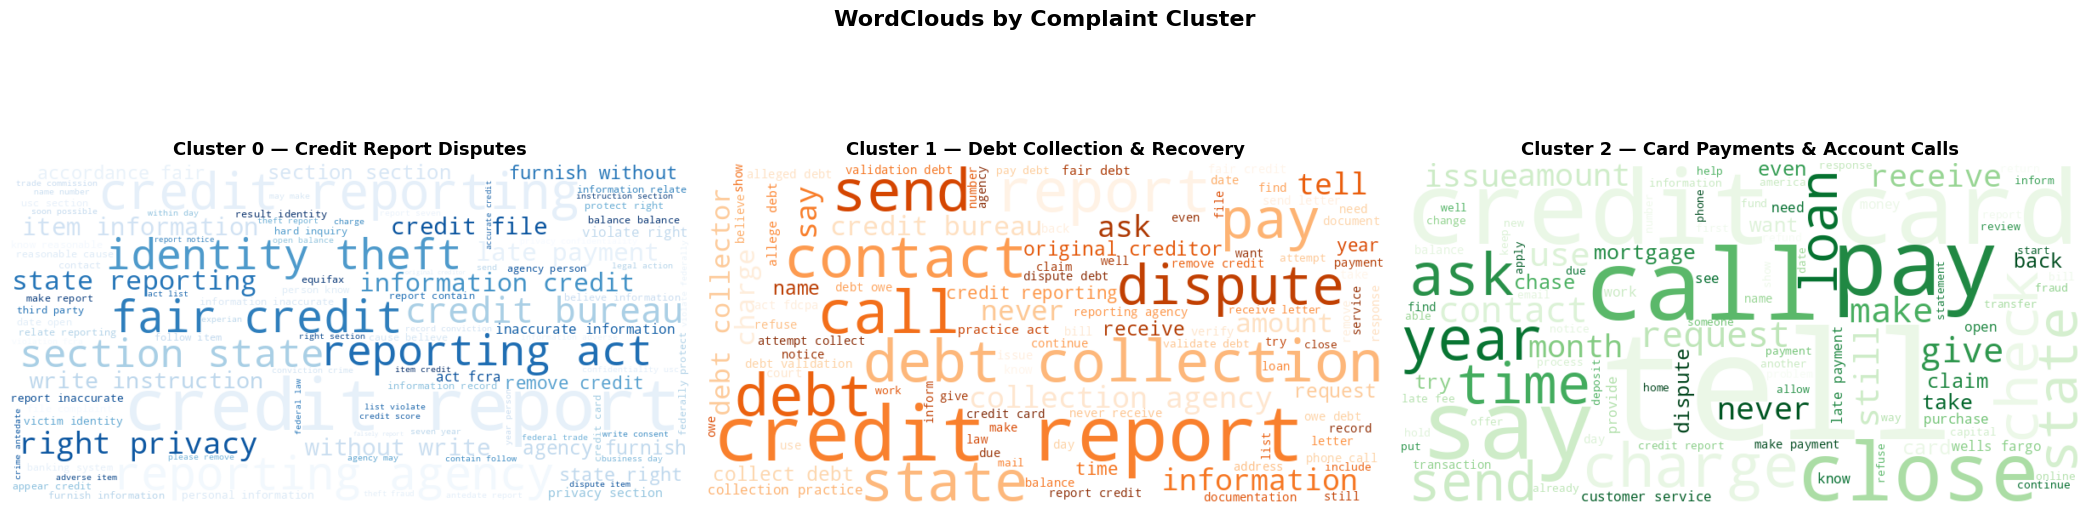

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

colormap_list = ["Blues", "Oranges", "Greens"]

for idx, c in enumerate(sorted(CLUSTER_LABELS.keys())):
    text = " ".join(df.loc[df["cluster"] == c, "text_processed"].dropna().tolist())
    wc = WordCloud(
        width=800, height=400,
        max_words=100,
        background_color="white",
        colormap=colormap_list[idx],
        random_state=RANDOM_STATE,
    ).generate(text)

    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Cluster {c} — {CLUSTER_LABELS[c]}", fontsize=13, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("WordClouds by Complaint Cluster", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.8 Export Summaries

In [16]:
best_summaries = []

for c in sorted(CLUSTER_LABELS.keys()):
    summaries = all_summaries[c]
    lengths   = [len(s.split()) for s in summaries]
    best_idx  = int(np.argmax(lengths))
    best_summaries.append({
        "cluster":       c,
        "label":         CLUSTER_LABELS[c],
        "summary":       summaries[best_idx],
        "word_count":    lengths[best_idx],
        "batch_idx":     best_idx,
        "rouge1_consistency": rouge_df.loc[rouge_df["cluster"] == c, "rouge1_mean"].values[0],
    })

summary_df = pd.DataFrame(best_summaries)
summary_path = f"{SUM_DIR}/cluster_summaries.csv"
summary_df.to_csv(summary_path, index=False)
print(f"✓ Saved: {summary_path}\n")

print("=" * 90)
print("  FINAL CLUSTER SUMMARIES")
print("=" * 90)
for _, row in summary_df.iterrows():
    print(f"\n  Cluster {int(row['cluster'])} — {row['label']}")
    print(f"  ROUGE-1 consistency: {row['rouge1_consistency']:.4f}  |  Words: {int(row['word_count'])}")
    print(f"  Summary:")
    print(f"    {row['summary']}")
print("\n" + "=" * 90)

print(f"\nArtifacts produced:")
for f in ["06_rouge_scores.png", "06_wordclouds.png"]:
    fp = f"{FIG_DIR}/{f}"
    print(f"  {fp:<65s}  {os.path.getsize(fp) / 1e6:.2f} MB")
print(f"  {summary_path:<65s}  {os.path.getsize(summary_path) / 1e6:.2f} MB")

✓ Saved: /content/drive/MyDrive/cfpb_pipeline/outputs/summaries/cluster_summaries.csv

  FINAL CLUSTER SUMMARIES

  Cluster 0 — Credit Report Disputes
  ROUGE-1 consistency: 0.3300  |  Words: 90
  Summary:
    i disputed this collection with after not agreeing to information on credit report now i have a missed payment on my credit report reporting from closed collection that has been charged off this is not right and should be removed. i am filing this complaint for falsely reporting misleading information there is no way for a company to falsely report incorrect information. my name is lvnv funding llc my credit card was closed on with revvi i don t understand why this company would falsely reported incorrect information on my

  Cluster 1 — Debt Collection & Recovery
  ROUGE-1 consistency: 0.2643  |  Words: 91
  Summary:
    i am disputing the collection account with account number dated year with a balance of this account is unverified and does not belong to me. i had my identity s